# ACTIVIDAD 2: REDES NEURONALES CONVOLUCIONALES

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar diez clases que incluyen fundamentalmente animales y vehículos.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs. *Nota: para leer las imágenes y estandarizarlas al mismo tamaño se usa la librería opencv. Esta ĺibrería está ya instalada en el entorno de Colab, pero si trabajáis de manera local tendréis que instalarla.*

<center><img src="https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png" style="text-align: center" height="300px"></center>

El dataset a utilizar consiste en 60000 imágenes a color de 10 clases de animales y vehículos. El dataset en cuestión se denomina [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) y es más complejo que el dataset MNIST que hemos utilizado en la actividad 1. Aunque tiene las mismas clases (10), los animales y vehículos pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros animales/ vehículos en pantalla (si bien el elemento a clasificar siempre aparece en la posición predominante).

## Carga de los datos

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import keras.datasets.cifar10 as cifar10

from tensorflow import keras
import keras
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Primero, definimos los datos de entrenamiento, validación y prueba
(X, Y), (x_test, y_test) = cifar10.load_data()
(x_train, x_valid) = (X[:40000], X[40000:])
(y_train, y_valid) = (Y[:40000], Y[40000:])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


In [4]:
# Normalizamos como de costumbre
x_train = x_train / 255.
x_valid = x_valid / 255.
x_test = x_test / 255.

In [5]:
# Esta variable contiene un mapeo de número de clase a elemento (animal o vehículo).
# La incluimos para ayudarte con la identificación de clases. De ti depende
# si quieres utilizar esta variable o no
MAP_ELEMENTS = {
    0: 'avion', 1: 'coche', 2: 'ave',
    3: 'gato', 4: 'ciervo', 5: 'perro', 6: 'rana',
    7: 'caballo', 8: 'barco', 9: 'camion'
}

In [6]:
# Función auxiliar para convertir las etiquetas a codificación one-hot
def convert_to_one_hot(labels, num_classes):
    return np.squeeze(np.array([to_categorical(label, num_classes=num_classes) for label in labels]))

# Convertimos las etiquetas de entrenamiento, validación y prueba
num_classes = 10
y_train_one_hot = convert_to_one_hot(y_train, num_classes)
y_valid_one_hot = convert_to_one_hot(y_valid, num_classes)
y_test_one_hot = convert_to_one_hot(y_test, num_classes)

# Verificamos las conversiones
print(y_train_one_hot.shape)
print(y_valid_one_hot.shape)
print(y_test_one_hot.shape)

(40000, 10)
(10000, 10)
(10000, 10)


## Ejercicio

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer una imagen de las incluidas en CIFAR-10 con la mayor accuracy posible. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos ni mucho menos, esto son ideas orientativas de aspectos que podéis explorar):

*   Análisis de los datos a utilizar.
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   [ *algo más difícil* ] Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.

Notas:
* Te recomendamos mantener los conjuntos de entrenamiento, test y prueba que se crean en el Notebook. No obstante, si crees que modificando tales conjuntos puedes lograr mejores resultados (o que puedes lograr los mismos resultados con menos datos, lo cual es también un logro), eres libre de hacerlo.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo del mejor modelo obtenido y la evaluación de los datos de test con este modelo**.

## Análisis exploratorio de los datos

Primero vamos a ver el tamaño de los datasets y las imágenes

In [12]:
print("Tamaño de una imagen (altura, anchura, canales):", x_train[0].shape)

print("Forma del conjunto de entrenamiento:", x_train.shape)
print("Forma del conjunto de validación:", x_valid.shape)
print("Forma del conjunto de test:", x_test.shape)


Tamaño de una imagen (altura, anchura, canales): (32, 32, 3)
Forma del conjunto de entrenamiento: (40000, 32, 32, 3)
Forma del conjunto de validación: (10000, 32, 32, 3)
Forma del conjunto de test: (10000, 32, 32, 3)


En la siguiente celda vamos a ver la primera imágen de cada clase del dataset

C:\Users\Usuario\AppData\Local\Temp\ipykernel_25136\1908163519.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(y_train[i])


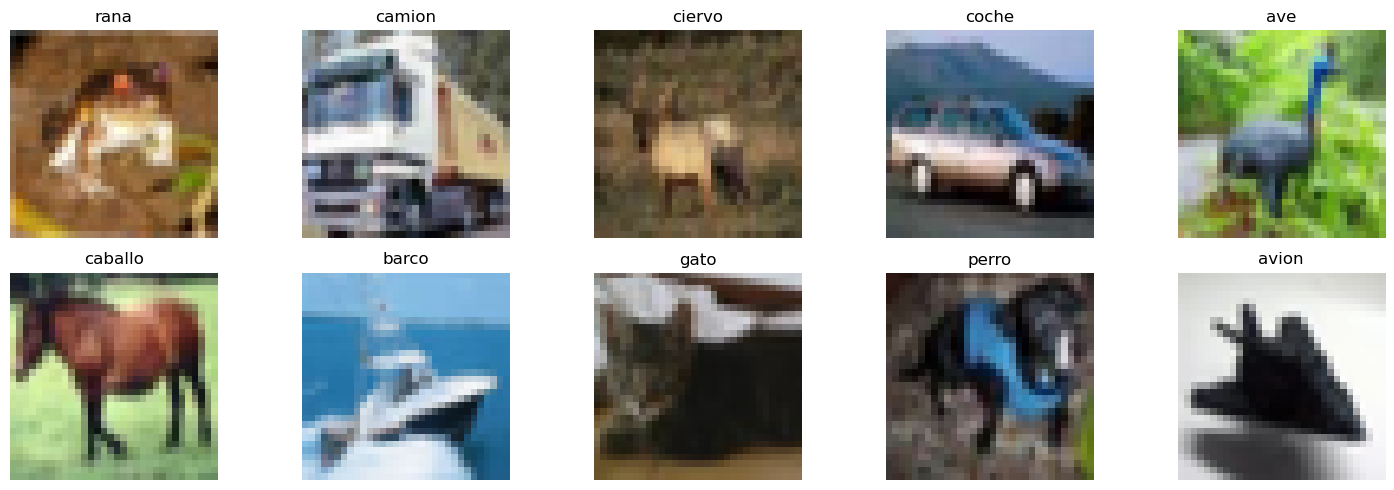

In [ ]:
samples = {}
for i in range(len(y_train)):
    label = int(y_train[i])
    if label not in samples:
        samples[label] = x_train[i]
    if len(samples) == 10:
        break

plt.figure(figsize=(15, 5))
for idx, (label, image) in enumerate(samples.items()):
    plt.subplot(2, 5, idx + 1)
    plt.imshow(image)
    plt.title(MAP_ELEMENTS[label])
    plt.axis('off')
plt.tight_layout()
plt.show()

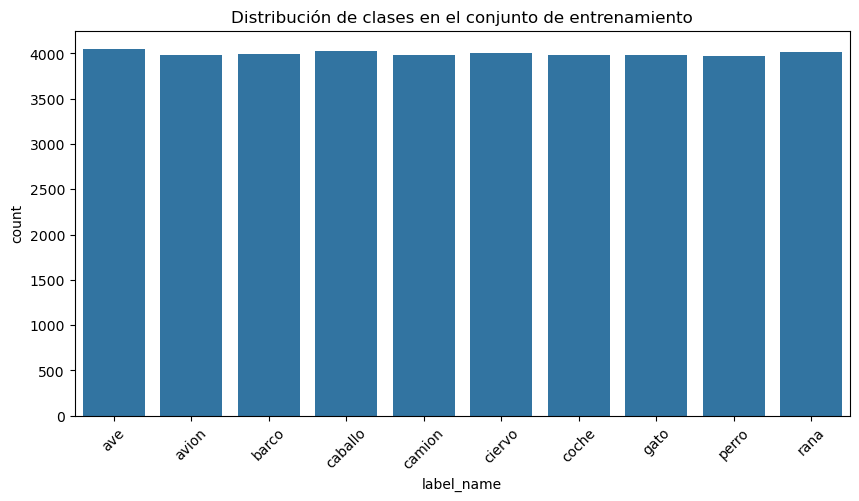

In [ ]:
df_labels = pd.DataFrame(y_train, columns=['label'])
df_labels['label_name'] = df_labels['label'].map(MAP_ELEMENTS)

# Gráfico de conteo
plt.figure(figsize=(10, 5))
sns.countplot(x='label_name', data=df_labels, order=sorted(MAP_ELEMENTS.values()))
plt.title("Distribución de clases en el conjunto de entrenamiento")
plt.xticks(rotation=45)
plt.show()


Como podemos ver, el dataset está muy balanceado, por lo que no habrá que tomar ninguna medida respecto a esto

## Modelos

### Perceptrón multicapa

Ya sabemos que un perceptrón multicapa no va a poder tener muy buenos resultados en un dataset con imágenes algo complejas. Vamos a ver los resultados para luego poder compararlo con los modelos de redes convolucionales.

In [23]:
x_train_flat = x_train.reshape((x_train.shape[0], -1))
x_valid_flat = x_valid.reshape((x_valid.shape[0], -1))
x_test_flat = x_test.reshape((x_test.shape[0], -1))

model_configs = [
    [256],
    [512, 128],
    [1024, 512, 128]
]

In [24]:
results = []

for config in model_configs:
    model_name = 'x'.join(map(str, config))
    print(f"\nEntrenando MLP con arquitectura: {config}")

    model = Sequential()
    model.add(Input(shape=(x_train_flat.shape[1],)))

    for units in config:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(0.3))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train_flat, y_train_one_hot,
                        validation_data=(x_valid_flat, y_valid_one_hot),
                        epochs=20, batch_size=64, verbose=1)

    # Evaluación
    y_pred_probs = model.predict(x_test_flat)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test_one_hot, axis=1)

    # Reporte de métricas
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    df_report = pd.DataFrame(report).transpose()
    # Extraer métricas y renombrar filas con nombres de clase
    class_metrics = df_report.loc[:'9'][['precision', 'recall']]
    class_metrics.index = [MAP_ELEMENTS[int(i)] for i in class_metrics.index]
    results.append((model_name, class_metrics))


    # Matriz de confusión
    print(f"\nMatriz de confusión para modelo {config}")
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=MAP_ELEMENTS.values(),
                yticklabels=MAP_ELEMENTS.values())
    plt.title(f'Matriz de confusión - {model_name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()



Entrenando MLP con arquitectura: [256]
Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1956 - loss: 2.2399 - val_accuracy: 0.3108 - val_loss: 1.9330
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2604 - loss: 1.9740 - val_accuracy: 0.3268 - val_loss: 1.8736
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2796 - loss: 1.9422 - val_accuracy: 0.3373 - val_loss: 1.8421
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2841 - loss: 1.9259 - val_accuracy: 0.3537 - val_loss: 1.8213
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2930 - loss: 1.9051 - val_accuracy: 0.3579 - val_loss: 1.8107
Epoch 6/20
174/625 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2982 - loss: 1.8942

KeyboardInterrupt: 

In [ ]:
# Mostrar métricas en tabla por modelo
for name, metrics_df in results:
    print(f"\n=== Modelo {name} ===")
    print(metrics_df.round(3).to_string())

### Redes convolucionales

In [ ]:
# Modelo CNN
model = Sequential()

# Primera capa convolucional
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Segunda capa convolucional
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Tercera capa convolucional
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Capa densa final
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Regularización
model.add(Dense(num_classes, activation='softmax'))

# Compilación
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamiento
history = model.fit(x_train, y_train_one_hot,
                    validation_data=(x_valid, y_valid_one_hot),
                    epochs=20,
                    batch_size=64)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.3509 - loss: 1.8789 - val_accuracy: 0.5256 - val_loss: 1.3501
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5455 - loss: 1.2805 - val_accuracy: 0.6169 - val_loss: 1.0753
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6203 - loss: 1.0810 - val_accuracy: 0.5031 - val_loss: 1.5664
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6585 - loss: 0.9699 - val_accuracy: 0.5278 - val_loss: 1.4227
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6901 - loss: 0.8883 - val_accuracy: 0.6677 - val_loss: 0.9732
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7221 - loss: 0.7941 - val_accuracy: 0.6473 - val_loss: 1.0781
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7487 - loss: 0.7235 - val_accuracy: 0.6293 - val_loss: 1.1319
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7622 - loss: 0.6742 - val_acc